In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             recall_score,
                             precision_score,
                             f1_score)

# Load the saved feature data from Phase 3
X_train = np.load('../data/processed/X_train_features.npy')
X_val   = np.load('../data/processed/X_val_features.npy')
X_test  = np.load('../data/processed/X_test_features.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (2520, 38)
Validation: (540, 38)
Test:       (540, 38)


In [2]:
rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 decision trees voting together
    max_depth=20,           # how deep each tree can grow
    min_samples_split=5,    # minimum samples needed to split a node
    class_weight='balanced',# automatically handles crash/non-crash imbalance
    random_state=42,        # makes results reproducible
    n_jobs=-1               # uses all your CPU cores to train faster
)

print("Training Random Forest... (should take 10-30 seconds)")
rf_model.fit(X_train, y_train)
print("Done!")

Training Random Forest... (should take 10-30 seconds)
Done!


In [3]:
y_val_pred = rf_model.predict(X_val)

print("=== Validation Set Results ===")
print(classification_report(
    y_val, y_val_pred,
    target_names=['Non-crash', 'Crash']
))

=== Validation Set Results ===
              precision    recall  f1-score   support

   Non-crash       0.98      0.97      0.98       379
       Crash       0.94      0.96      0.95       161

    accuracy                           0.97       540
   macro avg       0.96      0.97      0.96       540
weighted avg       0.97      0.97      0.97       540



In [4]:
y_test_pred = rf_model.predict(X_test)

# Core metrics
recall    = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
fpr = fp / (fp + tn)    # false positive rate

print("=== Test Set Results ===")
print(f"Recall (crash):       {recall:.3f}   ← must be >= 0.95")
print(f"False positive rate:  {fpr:.3f}   ← must be <= 0.02")
print(f"Precision:            {precision:.3f}")
print(f"F1 score:             {f1:.3f}")
print(f"\nTP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")
print(f"\nIn plain English:")
print(f"  Crashes correctly detected:  {tp}")
print(f"  Crashes missed:              {fn}  ← want this as low as possible")
print(f"  False alarms:                {fp}  ← want this as low as possible")
print(f"  Correct non-crash:           {tn}")

=== Test Set Results ===
Recall (crash):       0.975   ← must be >= 0.95
False positive rate:  0.040   ← must be <= 0.02
Precision:            0.913
F1 score:             0.943

TP: 157  FP: 15  TN: 364  FN: 4

In plain English:
  Crashes correctly detected:  157
  Crashes missed:              4  ← want this as low as possible
  False alarms:                15  ← want this as low as possible
  Correct non-crash:           364


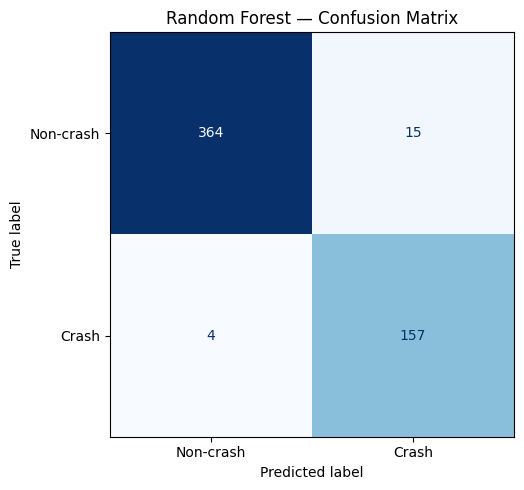

In [5]:
cm   = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-crash', 'Crash']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [6]:
os.makedirs('../models', exist_ok=True)
with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Random Forest model saved to ../models/random_forest.pkl")

Random Forest model saved to ../models/random_forest.pkl
